# This notebook is divided into the following parts:

### 1. Training and testing classical KAN architecture on MNIST dataset

  a. Training and Testing Efficient KAN on MNIST dataset

  b. Training and Testing BSRBF KAN on MNIST dataset

### 2. Possibilities of Quantum Implementations of KAN

  a. Chebyschev KAN using Block Encodings

  b. Furthur Variations from the original Q-KAN

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import f1_score, confusion_matrix
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
mnist_train = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
mnist_test = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# Split into train and validation sets
train_size = int(0.9 * len(mnist_train))
val_size = len(mnist_train) - train_size
train_dataset, val_dataset = random_split(mnist_train, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(mnist_test, batch_size=64, shuffle=False)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:01<00:00, 5.64MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 148kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.40MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 7.14MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



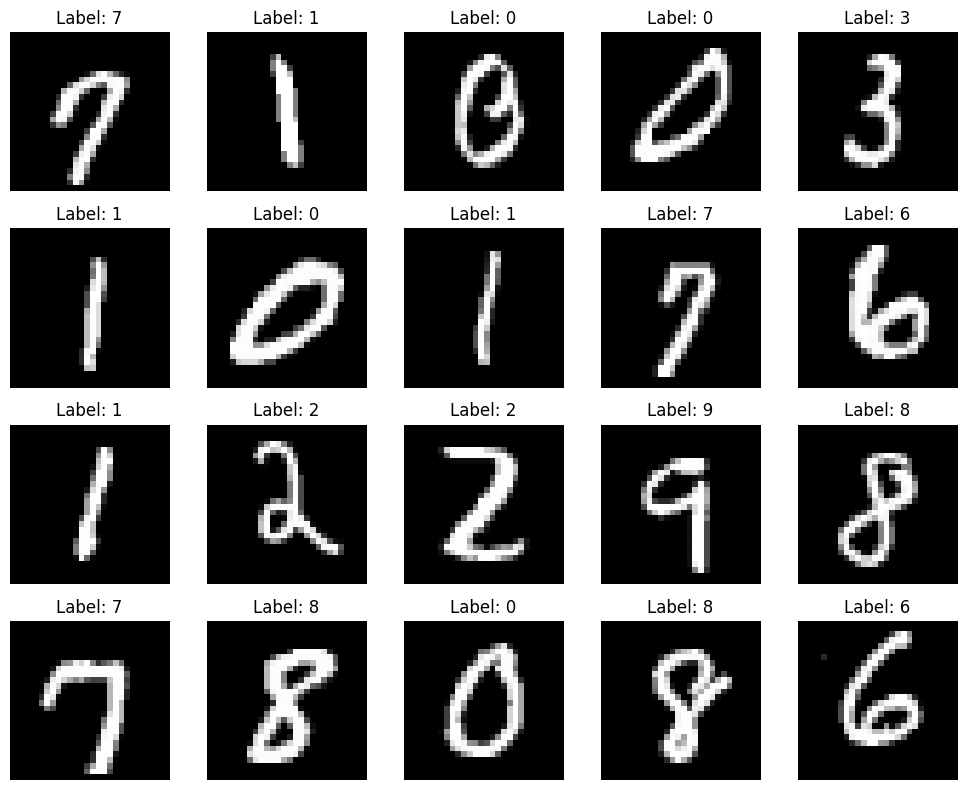

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 5, figsize=(10, 8))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    image = image.squeeze().numpy()
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()


# Efficient KAN
I have used a similar implementation as [Efficient KAN](https://github.com/Blealtan/efficient-kan). This implementation makes the computation more straightforward and memory efficient. One more thing in which this implementation differs from the original is the regularization. In the original paper, the regularization loss included two terms L1 regularization on the average activations from the activation functions plus entropy loss of KAN layers. But in this implementation the entropy regularization loss term have been dropped completely, while the L1 regularization has been changed to L1 regularization on weights, which is what usually done in classical neural networks. This change has shown to outperform the original regularization in the paper [BSRBF-KAN](https://arxiv.org/pdf/2406.11173).

In [ ]:
class KANLinear(torch.nn.Module):
    def __init__(self, inp_dim=2, out_dim=5, num=5, k=3, sn=0.1, sb=1.0, sp=1.0, spline_scale=True, base_f=torch.nn.SiLU, grid_range=[-1, 1]):
        super(KANLinear, self).__init__()
        self.inp_dim = inp_dim
        self.out_dim = out_dim
        self.num = num
        self.k = k
        self.sn = sn
        self.sb = sb
        self.sp = sp
        h = (grid_range[1] - grid_range[0]) / num
        grid = (torch.arange(-k, num + k + 1) * h + grid_range[0]).expand(inp_dim, -1).contiguous()
        self.register_buffer("grid", grid)

        self.base_weight = torch.nn.Parameter(torch.Tensor(out_dim, inp_dim))
        self.spline_weight = torch.nn.Parameter(torch.Tensor(out_dim, inp_dim, num + k))
        if spline_scale:
            self.spline_scaler = torch.nn.Parameter(torch.Tensor(out_dim, inp_dim))

        self.spline_scale = spline_scale
        self.base_f = base_f()
        self.reset_parameters()

    def reset_parameters(self):
        torch.nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5) * self.sb)
        with torch.no_grad():
            noise = ((torch.rand(self.num + 1, self.inp_dim, self.out_dim) - 0.5) * self.sn / self.num)
            self.spline_weight.data.copy_((self.sp if not self.spline_scale else 1.0) * self.curve2coeff(self.grid.T[self.k:-self.k], noise))
            if self.spline_scale:
                torch.nn.init.kaiming_uniform_(self.spline_scaler, a=math.sqrt(5) * self.sp)

    def b_splines(self, x: torch.Tensor):
        grid = self.grid
        x = x.unsqueeze(-1)
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
        for i in range(1, self.k + 1):
            bases = ((x - grid[:, :-(i+1)]) / (grid[:, i:-1] - grid[:, :-(i+1)]) * bases[:, :, :-1]) + ((grid[:, i+1:] - x) / (grid[:, i+1:] - grid[:, 1:-i]) * bases[:, :, 1:])
        return bases.contiguous()

    def curve2coeff(self, x: torch.Tensor, y: torch.Tensor):
        A = self.b_splines(x).transpose(0, 1)
        B = y.transpose(0, 1)
        solution = torch.linalg.lstsq(A, B).solution
        return solution.permute(2, 0, 1).contiguous()

    @property
    def scaled_spline_weight(self):
        return self.spline_weight * (self.spline_scaler.unsqueeze(-1) if self.spline_scale else 1.0)

    def forward(self, x: torch.Tensor):
        assert x.size(-1) == self.inp_dim
        original_shape = x.shape
        x = x.reshape(-1, self.inp_dim)
        base_output = F.linear(self.base_f(x), self.base_weight)
        spline_output = F.linear(self.b_splines(x).view(x.size(0), -1), self.scaled_spline_weight.view(self.out_dim, -1))
        return (base_output + spline_output).reshape(*original_shape[:-1], self.out_dim)

    def regularization_loss(self, reg_act=1.0, reg_ent=1.0):
        l1_fake = self.spline_weight.abs().mean(-1)
        reg_loss_act = l1_fake.sum()
        p = l1_fake / reg_loss_act
        reg_loss_ent = -torch.sum(p * p.log())
        return reg_act * reg_loss_act + reg_ent * reg_loss_ent

class KAN(torch.nn.Module):
    def __init__(self, architecture=[28 * 28, 128, 10], num=5, k=3, sn=0.1, sb=1.0, sp=1.0, base_f=torch.nn.SiLU, grid_range=[-1, 1]):
        super().__init__()
        self.layers = torch.nn.ModuleList([KANLinear(inp_dim, out_dim, num=num, k=k, sn=sn, sb=sb, sp=sp, base_f=base_f, grid_range=grid_range) for inp_dim, out_dim in zip(architecture, architecture[1:])])

    def forward(self, x: torch.Tensor):
        for layer in self.layers: x = layer(x)
        return x

    def regularization_loss(self, reg_act=1.0, reg_ent=1.0):
        return sum(layer.regularization_loss(reg_act, reg_ent) for layer in self.layers)

In [ ]:
# Initialize model, loss, optimizer and scheduler
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = KAN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

cuda


In [ ]:
for images, labels in train_loader:
    images, labels = (images.view(images.size(0), -1)).to(device), (labels.view(labels.size(0),-1)).to(device)
    outputs = model(images)
    print(images.shape)
    print(labels.shape)
    print(outputs.shape)
    break

torch.Size([64, 784])
torch.Size([64, 1])
torch.Size([64, 10])


In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10, device='cuda'):
    best_f1 = 0.0
    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = (images.view(images.size(0), -1)).to(device), (labels.view(labels.size(0),-1)).to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels.squeeze()) + (1/labels.size(0))*model.regularization_loss()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels.squeeze()).sum().item()
            total += labels.size(0)
        train_acc = correct / total
        scheduler.step()

        model.eval()
        val_correct, val_total = 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = (images.view(images.size(0), -1)).to(device), (labels.view(labels.size(0),-1)).to(device)
                outputs = model(images)
                val_correct += (outputs.argmax(1) == labels.squeeze()).sum().item()
                val_total += labels.size(0)
                all_preds.extend(outputs.argmax(1).cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        val_acc = val_correct / val_total
        val_f1 = f1_score(all_labels, all_preds, average='macro')

        print(f"Loss: {total_loss/len(train_loader):.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), f"best_kan_mnist.pth")
            print(f"Best model saved with F1: {best_f1:.4f}")

In [ ]:
train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs = 50)

Epoch 1/50: 100%|██████████| 844/844 [00:14<00:00, 57.66it/s]


Loss: 0.8311, Train Acc: 0.9191, Val Acc: 0.9507, Val F1: 0.9500
Best model saved with F1: 0.9500


Epoch 2/50: 100%|██████████| 844/844 [00:14<00:00, 60.07it/s]


Loss: 0.5349, Train Acc: 0.9659, Val Acc: 0.9648, Val F1: 0.9642
Best model saved with F1: 0.9642


Epoch 3/50: 100%|██████████| 844/844 [00:14<00:00, 59.75it/s]


...

Loss: 0.0598, Train Acc: 1.0000, Val Acc: 0.9818, Val F1: 0.9815


Epoch 49/50: 100%|██████████| 844/844 [00:13<00:00, 61.01it/s]


Loss: 0.0365, Train Acc: 1.0000, Val Acc: 0.9817, Val F1: 0.9814


Epoch 50/50: 100%|██████████| 844/844 [00:13<00:00, 61.50it/s]


Loss: 0.0193, Train Acc: 1.0000, Val Acc: 0.9817, Val F1: 0.9814


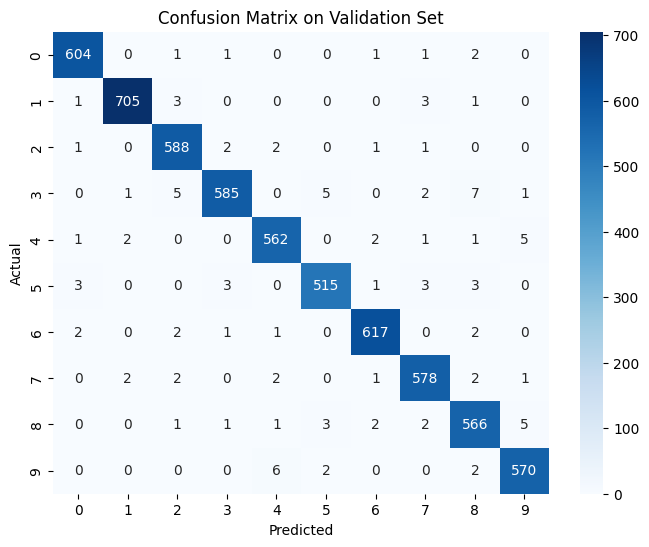

In [ ]:
def plot_confusion_matrix(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = (images.view(images.size(0), -1)).to(device), (labels.view(labels.size(0),-1)).to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.squeeze().cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix on Validation Set")
    plt.show()

# Call this function after training
plot_confusion_matrix(model, val_loader)


In [ ]:
model_test = KAN()
model_test.load_state_dict(torch.load("best_kan_mnist.pth", map_location=device))
model_test.to(device)
model_test.eval()

<ipython-input-12-e48ceebe61cc>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_test.load_state_dict(torch.load("best_kan_mnist.pth", map_location=device))


KAN(
  (layers): ModuleList(
    (0-1): 2 x KANLinear(
      (base_f): SiLU()
    )
  )
)

Test Accuracy: 0.9808, F1 Score: 0.9806


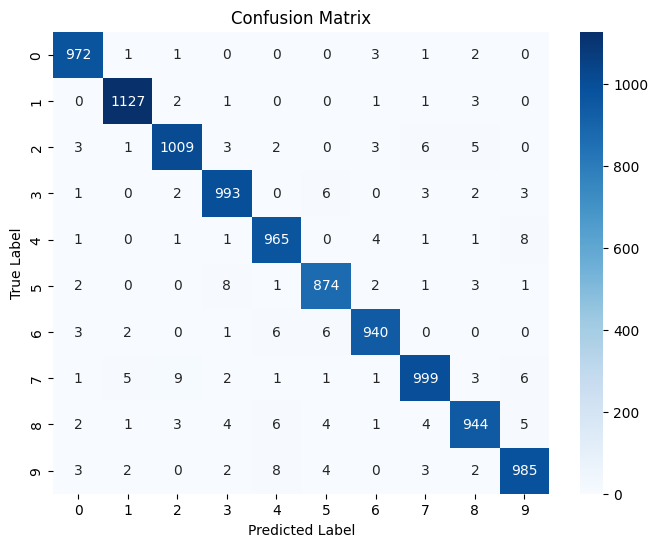

In [ ]:
test_correct, test_total = 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.view(images.size(0), -1).to(device), labels.to(device)

        outputs = model_test(images)
        preds = outputs.argmax(dim=1)

        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = test_correct / test_total
test_f1 = f1_score(all_labels, all_preds, average="macro")

print(f"Test Accuracy: {test_acc:.4f}, F1 Score: {test_f1:.4f}")

# Plot Confusion Matrix
conf_matrix = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.savefig("test_confusion_matrix_mnist.png", dpi=300, bbox_inches="tight")  # Save as PNG
plt.show()

**Analysing the results:**
We achieved a multiclass F1 score of 0.9806 on test dataset, which is pretty good considering that we did no hyperparameter tuning. Also we must keep in mind that KANs or even MLPs exhibit no inductive biases that might have helped in case of this MNIST dataset, compared to CNNs.

# BSRBF-KAN

[BSRBF-KAN](https://arxiv.org/pdf/2406.11173) uses a combination of Radial Basis Functions(RBF) and B-splines, hence the name. Both functions are smooth and hence continuous and differential upto a certain order. Radial Basis Functions are known to be good function approximators.

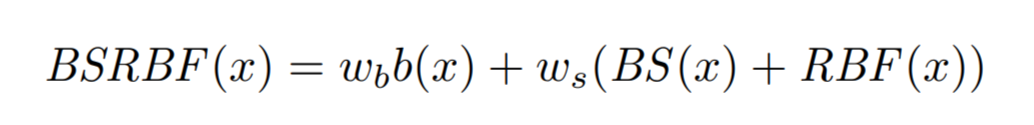

In [ ]:
class RadialBasisFunction(nn.Module):
    def __init__(self, grid_min=-1.5, grid_max=1.5, num_grids=8, denominator=None):
        super().__init__()
        grid = torch.linspace(grid_min, grid_max, num_grids)
        self.grid = nn.Parameter(grid, requires_grad=False)
        self.denominator = denominator or (grid_max - grid_min) / (num_grids - 1)

    def forward(self, x):
        return torch.exp(-((x[..., None] - self.grid) / self.denominator) ** 2)

class BSRBF_KANLayer(nn.Module):
    def __init__(self, input_dim, output_dim, grid_size=5, spline_order=3, base_activation=nn.SiLU, grid_range=[-1.5, 1.5]):
        super().__init__()
        self.layernorm = nn.LayerNorm(input_dim)
        self.spline_order, self.grid_size, self.output_dim, self.input_dim = spline_order, grid_size, output_dim, input_dim
        self.base_activation = base_activation()
        self.base_weight = nn.Parameter(torch.Tensor(output_dim, input_dim))
        self.spline_weight = nn.Parameter(torch.Tensor(output_dim, input_dim * (grid_size + spline_order)))
        nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5))
        nn.init.kaiming_uniform_(self.spline_weight, a=math.sqrt(5))
        self.rbf = RadialBasisFunction(grid_range[0], grid_range[1], grid_size + spline_order)
        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = (torch.arange(-spline_order, grid_size + spline_order + 1) * h + grid_range[0]).expand(input_dim, -1).contiguous()
        self.register_buffer("grid", grid)

    def b_splines(self, x):
        x, grid = x.unsqueeze(-1), self.grid
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
        for k in range(1, self.spline_order + 1):
            bases = ((x - grid[:, :-(k+1)]) / (grid[:, k:-1] - grid[:, :-(k+1)]) * bases[:, :, :-1]) + \
                    ((grid[:, k+1:] - x) / (grid[:, k+1:] - grid[:, 1:-k]) * bases[:, :, 1:])
        return bases.contiguous()

    def forward(self, x):
        x = self.layernorm(x)
        base_output = F.linear(self.base_activation(x), self.base_weight)
        bs_output = self.b_splines(x).view(x.size(0), -1)
        rbf_output = self.rbf(x).view(x.size(0), -1)
        bsrbf_output = F.linear(bs_output + rbf_output, self.spline_weight)
        return base_output + bsrbf_output

class BSRBF_KAN(nn.Module):
    def __init__(self, layers_hidden, grid_size=5, spline_order=3, base_activation=nn.SiLU):
        super().__init__()
        self.layers = nn.ModuleList([BSRBF_KANLayer(input_dim, output_dim, grid_size, spline_order, base_activation)
                                     for input_dim, output_dim in zip(layers_hidden, layers_hidden[1:])])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
bsrbf_kan = BSRBF_KAN([28*28, 128, 10]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bsrbf_kan.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

cuda


In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10, device='cuda'):
    best_f1 = 0.0
    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = (images.view(images.size(0), -1)).to(device), (labels.view(labels.size(0),-1)).to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels.squeeze())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels.squeeze()).sum().item()
            total += labels.size(0)
        train_acc = correct / total
        scheduler.step()

        model.eval()
        val_correct, val_total = 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = (images.view(images.size(0), -1)).to(device), (labels.view(labels.size(0),-1)).to(device)
                outputs = model(images)
                val_correct += (outputs.argmax(1) == labels.squeeze()).sum().item()
                val_total += labels.size(0)
                all_preds.extend(outputs.argmax(1).cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        val_acc = val_correct / val_total
        val_f1 = f1_score(all_labels, all_preds, average='macro')

        print(f"Loss: {total_loss/len(train_loader):.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), f"best_kan_mnist.pth")
            print(f"Best model saved with F1: {best_f1:.4f}")

In [ ]:
train_model(bsrbf_kan, train_loader, val_loader, criterion, optimizer, scheduler, epochs = 50)

Epoch 1/50: 100%|██████████| 844/844 [00:14<00:00, 58.86it/s]


Loss: 0.3081, Train Acc: 0.9075, Val Acc: 0.9582, Val F1: 0.9579
Best model saved with F1: 0.9579


Epoch 2/50: 100%|██████████| 844/844 [00:14<00:00, 59.21it/s]


Loss: 0.1156, Train Acc: 0.9649, Val Acc: 0.9625, Val F1: 0.9623
Best model saved with F1: 0.9623


Epoch 3/50: 100%|██████████| 844/844 [00:14<00:00, 59.65it/s]


...

Loss: 0.0000, Train Acc: 1.0000, Val Acc: 0.9817, Val F1: 0.9817


Epoch 49/50: 100%|██████████| 844/844 [00:14<00:00, 59.52it/s]


Loss: 0.0000, Train Acc: 1.0000, Val Acc: 0.9817, Val F1: 0.9817


Epoch 50/50: 100%|██████████| 844/844 [00:14<00:00, 59.41it/s]


Loss: 0.0000, Train Acc: 1.0000, Val Acc: 0.9817, Val F1: 0.9817


In [ ]:
model_test = BSRBF_KAN([28*28, 128, 10])
model_test.load_state_dict(torch.load("best_kan_mnist.pth", map_location=device))
model_test.to(device)
model_test.eval()

<ipython-input-10-75d769415fbf>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_test.load_state_dict(torch.load("best_kan_mnist.pth", map_location=device))


BSRBF_KAN(
  (layers): ModuleList(
    (0): BSRBF_KANLayer(
      (layernorm): LayerNorm((784,), eps=1e-05, elementwise_affine=True)
      (base_activation): SiLU()
      (rbf): RadialBasisFunction()
    )
    (1): BSRBF_KANLayer(
      (layernorm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (base_activation): SiLU()
      (rbf): RadialBasisFunction()
    )
  )
)

Test Accuracy: 0.9821, F1 Score: 0.9819


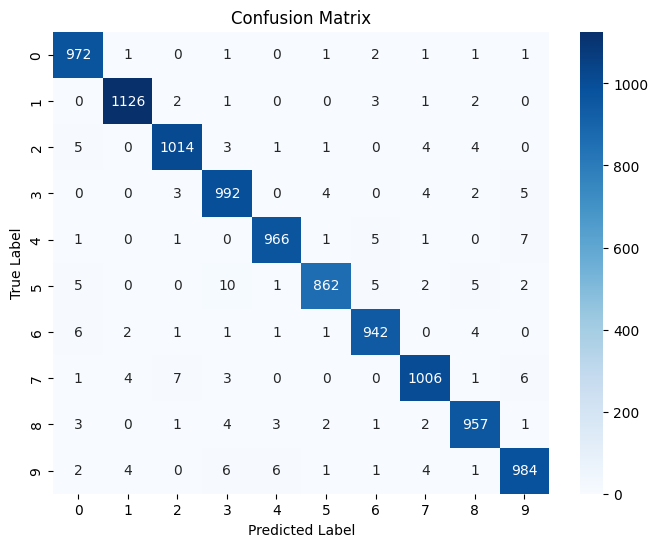

In [ ]:
test_correct, test_total = 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.view(images.size(0), -1).to(device), labels.to(device)

        outputs = model_test(images)
        preds = outputs.argmax(dim=1)

        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = test_correct / test_total
test_f1 = f1_score(all_labels, all_preds, average="macro")

print(f"Test Accuracy: {test_acc:.4f}, F1 Score: {test_f1:.4f}")

# Plot Confusion Matrix
conf_matrix = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.savefig("test_confusion_matrix_mnist.png", dpi=300, bbox_inches="tight")  # Save as PNG
plt.show()

**Analysis of results:**
BSRBF-KAN achives a test F1 score of 0.9819 outperforming Efficient KAN, again with no hyperparameter tuning, suggesting that combination of RBFs and B-splines are better function approximators than just a standalone B-splines KAN.

# Potential Ideas for extending the classical KAN architecture to a Quantum KAN

**I've proposed two ways to extend KAN to a quantum implementation:**

1. *Chebyschev KAN using Block Encodings*
2. *Furthur Variations from the original Q-KAN*

# 1. Chebyschev KAN using Block Encodings

As proposed in the paper [CHEB-QKAN](https://arxiv.org/pdf/2410.04435), we can use block encodings as the fundamental idea upon which our whole implementation will be based. Block encoding is a technique used to encode a matrix into another matrix(a unitary matrix), in an extended Hilbert space. Since quantum computers naturally work on unitary matrices hence this technique is very useful. This model starts from this encoding and also ends at these encodings.

**Model Architecture:**

The classical KAN architecture is defined as:
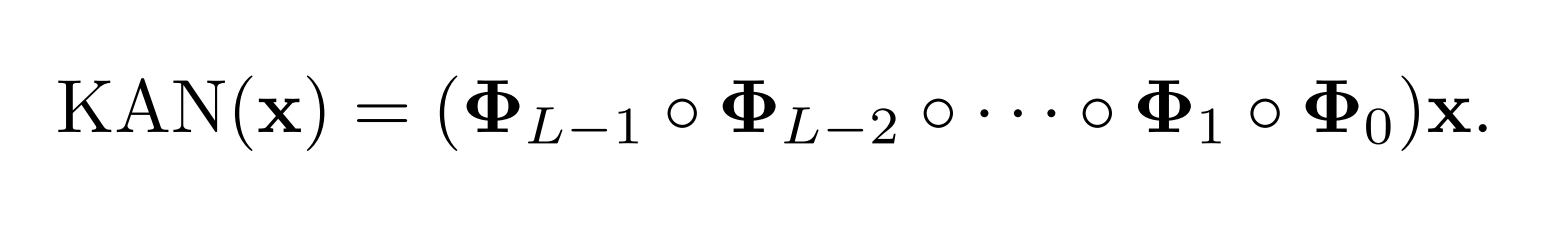

where $\phi_l$ denotes a function matrix of dimension $(n_{\text{out}}, n_{\text{inp}})$, every element of the matrix denotes a learnable function (edge) connecting the $i$th neuron of the previous layer to the $j$th neuron of the next layer.
The most common choice of these functions are B-splines ([ref.](https://arxiv.org/pdf/2404.19756)), Chebyshev Polynomials ([ref.](https://arXiv:2405.07200)), Fourier Transforms ([ref.](https://arXiv:2406.01034)), Radial basic functions ([ref.](https://arXiv:2406.11173)), and even a combination of B-splines and RBF([ref.](https://arXiv:2406.11173)).

In this quantum implementation of KAN, linear combination of Chebyschev polynomials have been used as the learnable function. The choice comes from the fact that Chebyschev polynomials can be efficiently realized using block encodings.
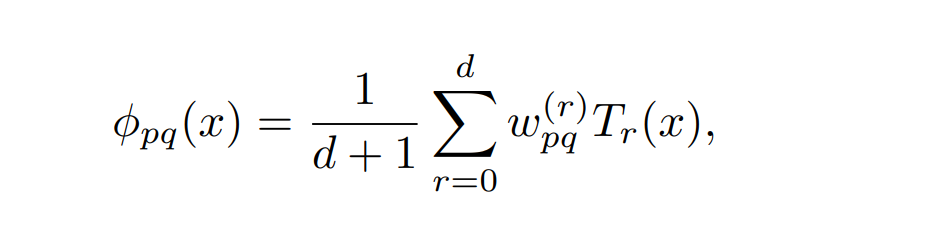

where $T_{r}{(x)}$ is the $r_{th}$ degree Chebyschev polynomial of the first kind. These polynomials are recursively defined as:

$$
\begin{aligned}
    T_{0}(x) &= 1, \\
    T_{1}(x) &= x, \\
    T_{n+1}(x) &= 2x \, T_{n}(x) - T_{n-1}(x).
\end{aligned}
$$

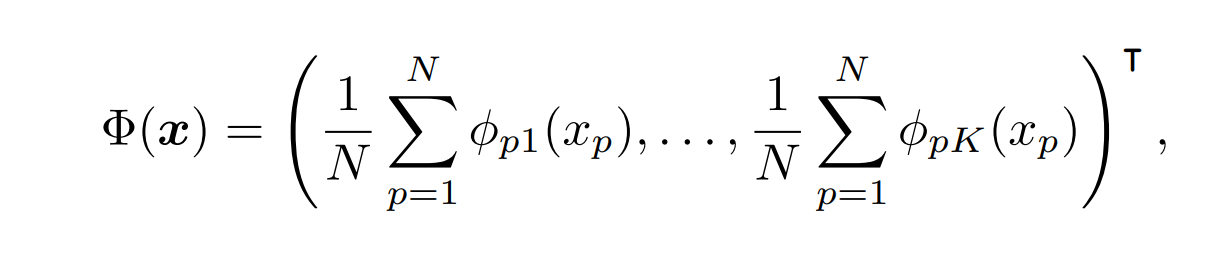

**The construction of the original model given in the paper envolves five major steps:**

**1. Dilate :** We need $k = \log_2 K$ additional qubits to accommodate the output nodes. Hence, we need to expand the input block encoding of the $N$-dimensional input vector by copying the input vector $K$ times. As proved in the paper, the block encoding of the $K$-times copied input vector can be computed using the following formulation:

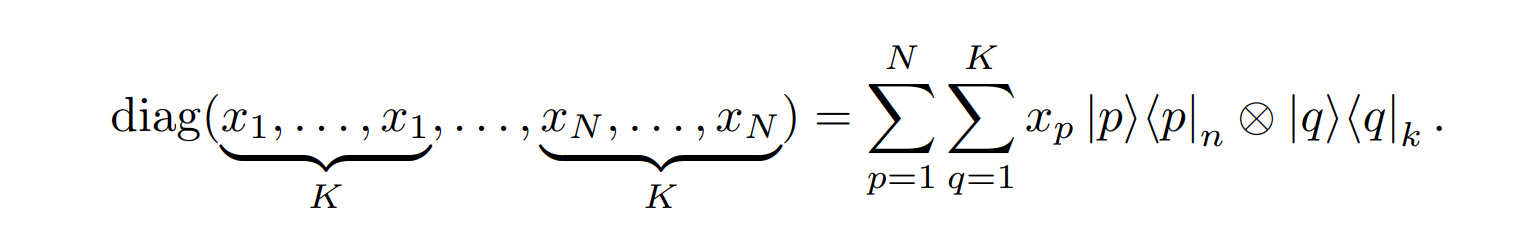

which can be realized from the below circuit:

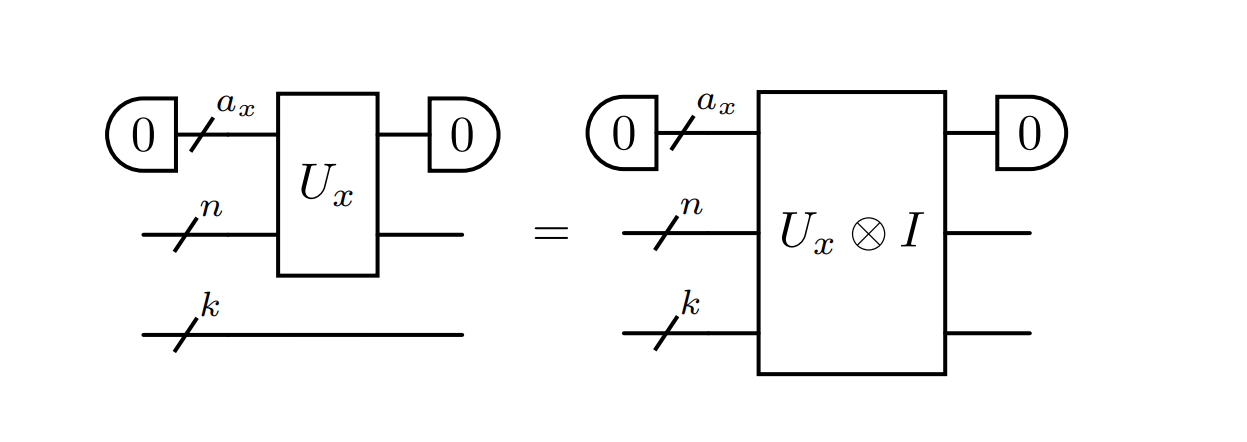

**2. Block Encode theChebyshev Polynomials:** The Chebyshev polynomials of first kind have chosen as the function approximators because it can be efficiently realized using Quantum Singular Value Transformation (QSVT).


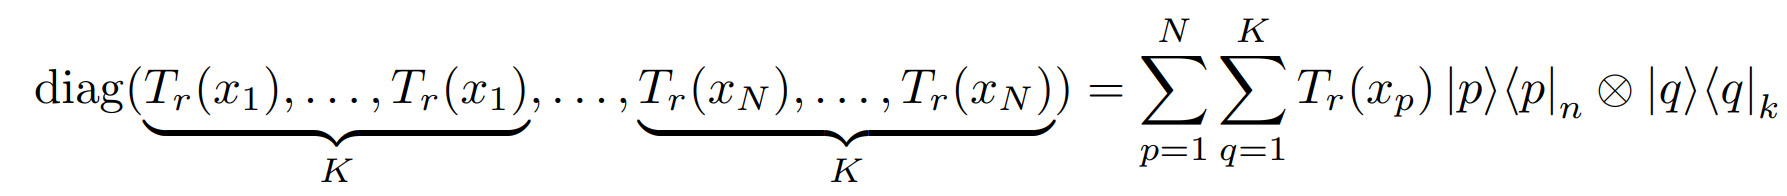

QSVT (Quantum Singular Value Transformation): is a framework that allows quantum computers to apply polynomial transformations to the singular values of a matrix.

### Key Idea of QSVT

Singular Value Decomposition (SVD): Any matrix $A$ can be decomposed as  
$$ A = U \Sigma V^\dagger $$  
where $U$ and $V$ are unitary matrices, and Σ is a diagonal matrix with singular values.  

Then, QSVT allows us to apply a function $P(x)$ which is a polynomial directly to the singular values:

$$A' = U P(\Sigma) V^\dagger$$

This means that any function that can be approximated by a polynomial can be applied to the singular values of $A$ in a quantum circuit.


To realize chebyshev polynomials in quantum circuit, We use $U_x$ and $U_x^\dagger$ interleaved by reflection operators, where $U_x^\dagger$ represents the adjoint (Hermitian conjugate) of $U_x$. And the reflection operator is $Z_{\pi} := I \otimes (2 |0\rangle \langle0|_{ax} - I_{ax})$

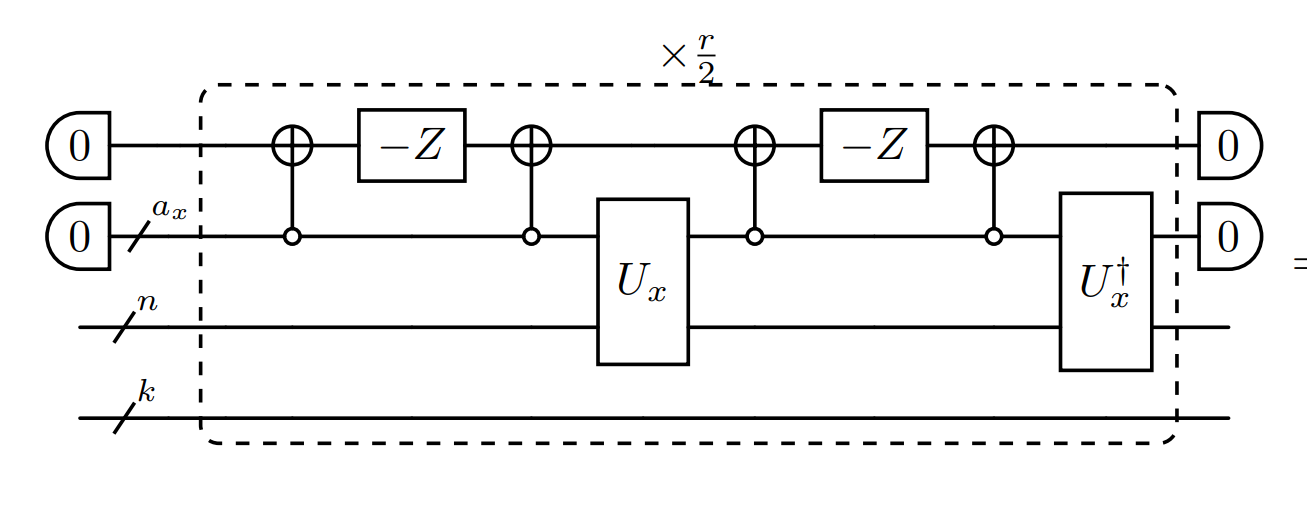

We repeat this step for $d+1$ times to create separate block encodings for each chebyshev polynomial of degree ranging from $0$ to $d$.

This requires 1 extra ancilla qubit.

**3. Multiplying with weight Unitary:**
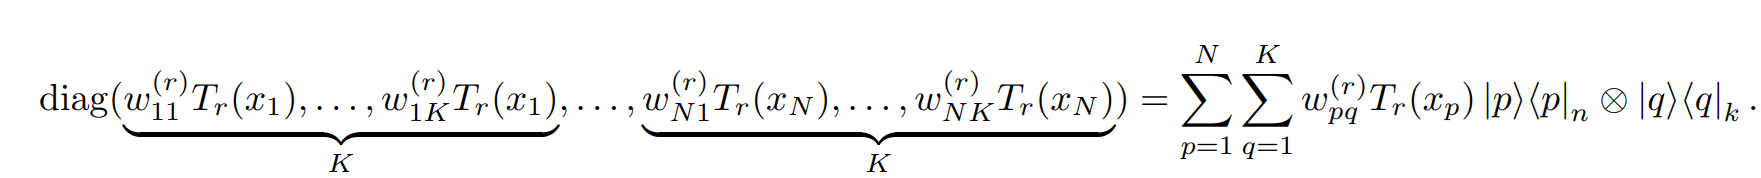

The weights are provided in the form of $d + 1$ diagonal block-encodings  
of $NK$-dimensional real weight vectors $w_r$, denoted by $U_{w_r}$.

$w^{(r)}_{pq}$ is the weight of the $r$-th Chebyshev polynomial in the activation function between the $p$-th input node and the $q$-th output node.

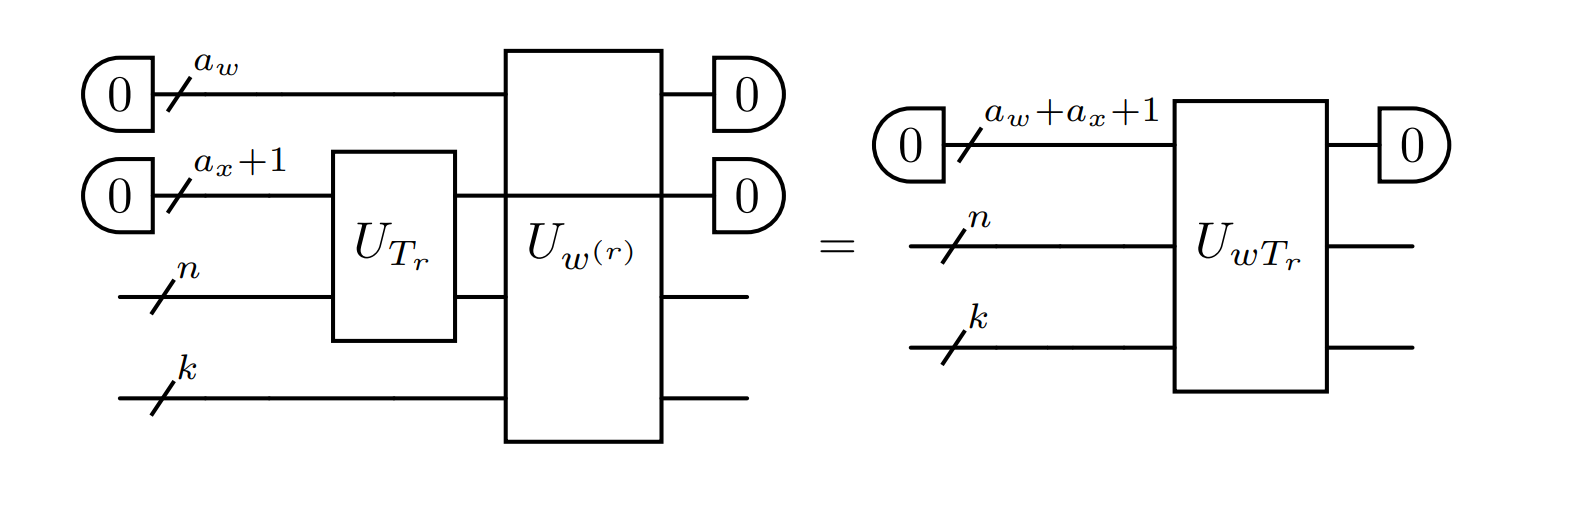

**4. LCU:** Linear combination of Unitaries method combines $d + 1$ weighted block-encodings of Chebyshev polynomials using an equal superposition,  resulting in a block-encoding of the activation function matrix, denoted by $U_{\phi}$.


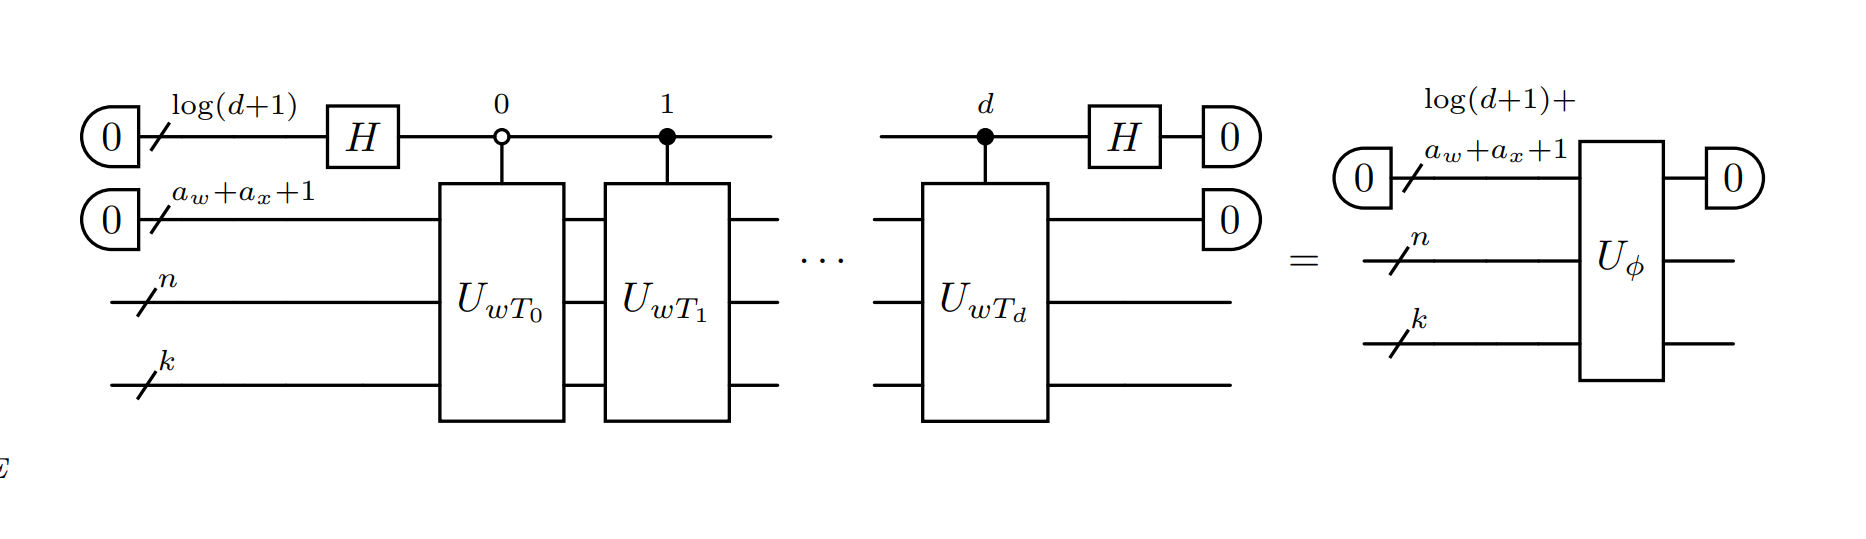

**5. Summation of individual outputs:** Using the block-encoding $U_{\phi}$ of individual activation functions, get the summation of $N$ inputs for each of the $K$ output nodes.


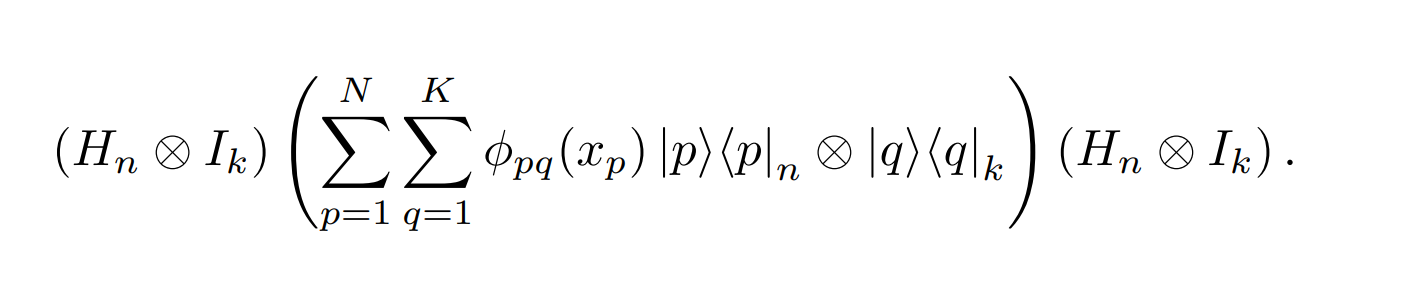

Block encoding $U_{\phi}$ is applied with two $n$-qubit Hadamard gates.

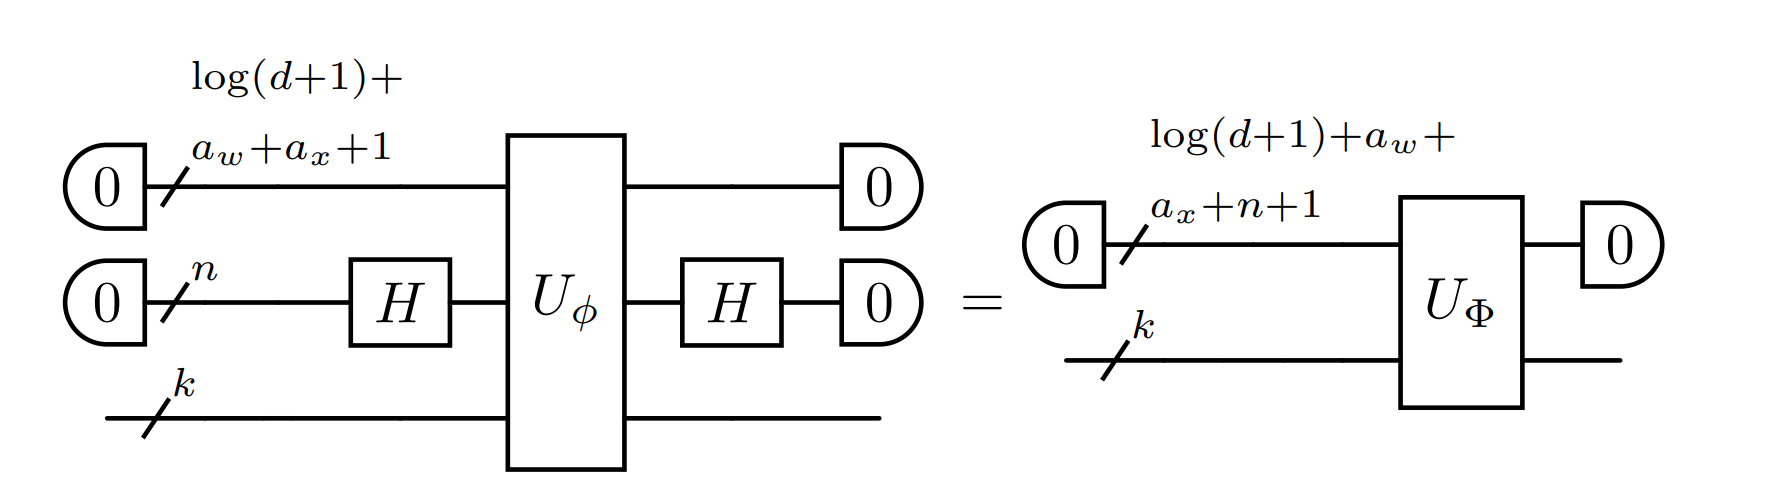

**Stacking up layers:** The notion of layer in this quantum implementation of KAN is different from the classical, as we cannot just stack the layers that we do in KAN or MLP. Here, each subsequent layer is built recursively from the previous layer. So we can understand this Q-KAN layer as transformation which maps an input block-encoding size of N to an output block-encoding of size K.

**Number of ancilla qubits required**: The final number of ancilla qubits required for the complete circuit implementation of L layer KAN (including the input layer) is:
$a^{(0)} _{x} + \sum_{l=1}^{L-1} \left( 1 + a^{(l)} _{w} + \log_2 (d + 1) + \log_2 N^{(l-1)} \right)$ , where $a^{(0)} _{x}$ denotes the number of ancilla qubits required for diagonal block encoding of $x$, which we can use as $n+2$,  while $a^{(l)} _{w}$ denotes ancilla qubits required to block encode the weight matrix of the $l_{th}$ layer.

#2. Furthur Variations from Original Q-KAN:
Till now, I've tried to replicate the [paper](https://https://arxiv.org/pdf/2410.04435) as a baseline. As suggested in the this paper, furthur variations and changes can be made to this architecture which are worth exploring.


**1. Trying different basis functions:** QSVT allows us to approximate functions with polynomials. Chebyshev Polynomials are special because they provide near-optimal polynomial approximations with minimal error in the uniform norm. However, different choices of functions affect the representational power of models differently.

**Periodic functions** (such as trigonometric functions) are naturally well-suited for polynomial approximations ([paper ref.](https://arxiv.org/pdf/2006.09661)), which are central to QSVT. This makes them useful in learning representations that can be efficiently encoded in quantum circuits.

### Idea : Using Fourier coefficients
The Fourier Transform (FT) approximates (or splits) a function (or signal) into a sum of sinusoidal components (sines and cosines) of different frequencies. It helps analyze signals in the frequency domain instead of the time or spatial domain.

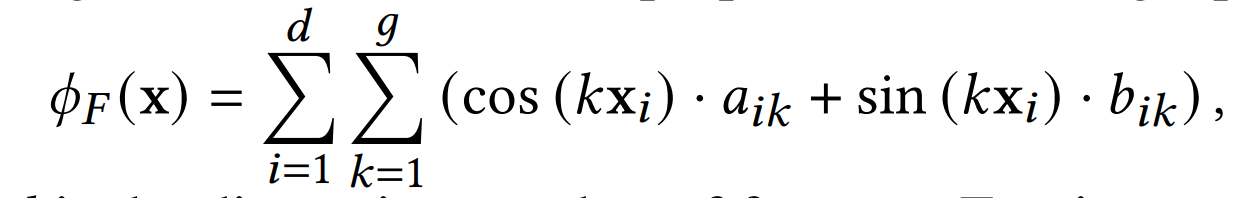

where $a_{ik}$ and $b_{ik}$ are Fourier coefficients corresponding to the sine and cosine part.

Fourier Coefficients have been previously explored in classical KAN architectures as well. ([Fourier-KAN](https://arxiv.org/pdf/2406.01034))

Fourier coefficients naturally encode periodic functions, making them ideal for capturing patterns in data with periodic structures.

Unlike Chebyshev polynomials, which are optimized only in a specific domain, Fourier series can model global periodic structures more effectively.

Many real-world data distributions (e.g., signals, spatial patterns) have periodic components, making Fourier-based activations more interpretable. This will be benificial for High Energy Physics Analysis.

This idea is still in its early stages. There are several aspects that require further research and refinement to ensure it is well-structured and feasible. Developing this idea into a comprehensive proposal will take time and effort, and I am willing to actively pursue and work on it to bring it to a more concrete form.